Correlations with continuous 'contact_state':
Accel Magnitude: 0.2657
Acc X: 0.1420
Acc Y: -0.0324
Acc Z: -0.0268
Correlations with continuous 'contact_state':
Accel Magnitude: 0.1638
Acc X: 0.1420
Acc Y: -0.0324
Acc Z: -0.0268


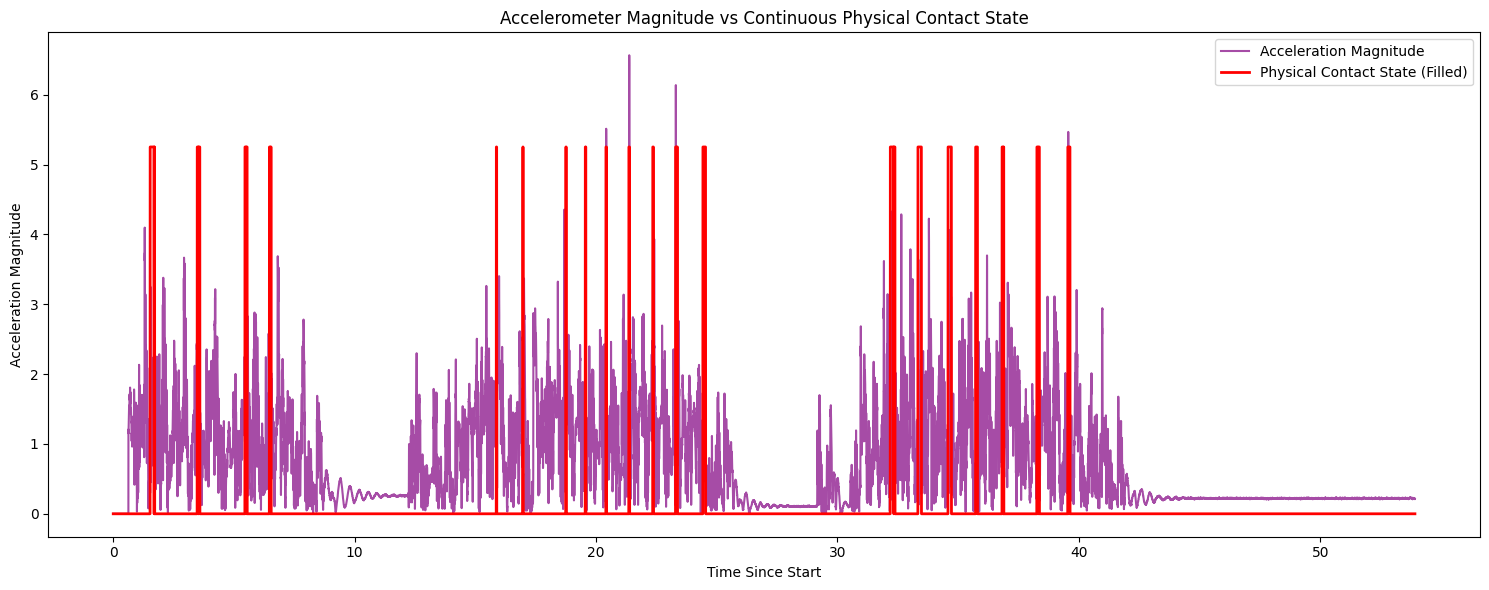

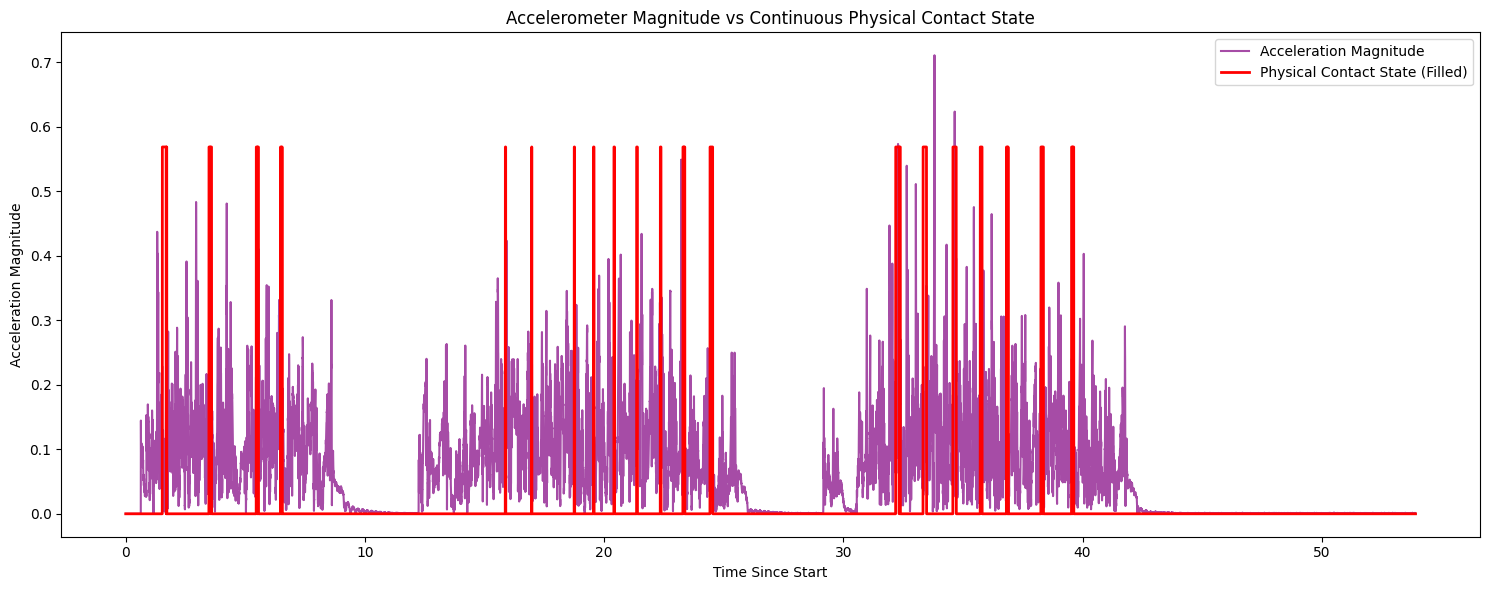

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('left_front_shoulder_1.csv')

# Create the continuous contact state by forward-filling the events
# 1 = start contact, 0 = end contact. NaNs in between mean the state hasn't changed.
df['contact_state'] = df['physical_contact'].ffill().fillna(0) 

# Calculate the magnitude of the acceleration vector
df['accel_magnitude'] = np.sqrt(
    df['imu_linear_acceleration_x'].pow(2) + 
    df['imu_linear_acceleration_y'].pow(2) + 
    df['imu_linear_acceleration_z'].pow(2)
)
df['angular_vel_magnitude'] = np.sqrt(
    df['imu_angular_velocity_x']**2 + 
    df['imu_angular_velocity_y']**2 + 
    df['imu_angular_velocity_z']**2
)
# Calculate the correlations
corr_mag = df[['contact_state', 'accel_magnitude']].corr().iloc[0, 1]
corr_x = df[['contact_state', 'imu_linear_acceleration_x']].corr().iloc[0, 1]
corr_y = df[['contact_state', 'imu_linear_acceleration_y']].corr().iloc[0, 1]
corr_z = df[['contact_state', 'imu_linear_acceleration_z']].corr().iloc[0, 1]

print("Correlations with continuous 'contact_state':")
print(f"Accel Magnitude: {corr_mag:.4f}")
print(f"Acc X: {corr_x:.4f}")
print(f"Acc Y: {corr_y:.4f}")
print(f"Acc Z: {corr_z:.4f}")

# Plotting
plt.figure(figsize=(15, 6))

# Plot magnitude
plt.plot(df['time_since_start'], df['accel_magnitude'], label='Acceleration Magnitude', color='purple', alpha=0.7)

# Plot raw axes lightly
# plt.plot(df['time_since_start'], df['imu_linear_acceleration_x'], label='Acc X', alpha=0.3)
# plt.plot(df['time_since_start'], df['imu_linear_acceleration_y'], label='Acc Y', alpha=0.3)
# plt.plot(df['time_since_start'], df['imu_linear_acceleration_z'], label='Acc Z', alpha=0.3)

# Overlay the continuous contact state
# Scale it so it's visible next to the acceleration values
scale_factor = df['accel_magnitude'].max() * 0.8
plt.plot(df['time_since_start'], df['contact_state'] * scale_factor, label='Physical Contact State (Filled)', color='red', linestyle='-', linewidth=2)

plt.title('Accelerometer Magnitude vs Continuous Physical Contact State')
plt.xlabel('Time Since Start')
plt.ylabel('Acceleration Magnitude')
plt.legend()
plt.tight_layout()
plt.savefig('continuous_contact_plot.png')


# Calculate the correlations
corr_mag = df[['contact_state', 'angular_vel_magnitude']].corr().iloc[0, 1]
corr_x = df[['contact_state', 'imu_linear_acceleration_x']].corr().iloc[0, 1]
corr_y = df[['contact_state', 'imu_linear_acceleration_y']].corr().iloc[0, 1]
corr_z = df[['contact_state', 'imu_linear_acceleration_z']].corr().iloc[0, 1]

print("Correlations with continuous 'contact_state':")
print(f"Accel Magnitude: {corr_mag:.4f}")
print(f"Acc X: {corr_x:.4f}")
print(f"Acc Y: {corr_y:.4f}")
print(f"Acc Z: {corr_z:.4f}")

# Plotting
plt.figure(figsize=(15, 6))

# Plot magnitude
plt.plot(df['time_since_start'], df['angular_vel_magnitude'], label='Acceleration Magnitude', color='purple', alpha=0.7)

# Plot raw axes lightly
# plt.plot(df['time_since_start'], df['imu_linear_acceleration_x'], label='Acc X', alpha=0.3)
# plt.plot(df['time_since_start'], df['imu_linear_acceleration_y'], label='Acc Y', alpha=0.3)
# plt.plot(df['time_since_start'], df['imu_linear_acceleration_z'], label='Acc Z', alpha=0.3)

# Overlay the continuous contact state
# Scale it so it's visible next to the acceleration values
scale_factor = df['angular_vel_magnitude'].max() * 0.8
plt.plot(df['time_since_start'], df['contact_state'] * scale_factor, label='Physical Contact State (Filled)', color='red', linestyle='-', linewidth=2)

plt.title('Accelerometer Magnitude vs Continuous Physical Contact State')
plt.xlabel('Time Since Start')
plt.ylabel('Acceleration Magnitude')
plt.legend()
plt.tight_layout()
plt.savefig('continuous_contact_plot.png')

In [ ]:
https://ollama.com/search?page=2

In [22]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt

# Load the data and calculate magnitude
df = pd.read_csv('left_front_shoulder_1.csv')
df['accel_magnitude'] = np.sqrt(df['imu_linear_acceleration_x']**2 + 
                                df['imu_linear_acceleration_y']**2 + 
                                df['imu_linear_acceleration_z']**2)

# Define the High-Pass Filter parameters
fs = 400.0          # Your IMU sampling frequency (calculated from your timestamps)
cutoff_freq = 5.0   # Cut out anything slower than 5 Hz (the walking sway)
nyquist = 0.5 * fs
normal_cutoff = cutoff_freq / nyquist

# Create a 4th-order Butterworth High-Pass Filter
b, a = butter(4, normal_cutoff, btype='high', analog=False)

# Apply the filter to the IMU data to remove the walking motion
df['accel_mag_walking_removed'] = filtfilt(b, a, df['accel_magnitude'])

# (Optional) Calculate the rolling variance of the clean signal to use as an ML feature
df['impact_vibration'] = df['accel_mag_walking_removed'].rolling(window=10).std()

Top features linearly correlated with contact_state:
contact_state                1.000000
physical_contact             1.000000
accel_magnitude              0.265703
angular_vel_magnitude        0.186670
imu_angular_velocity_y       0.157844
imu_angular_velocity_z      -0.148639
act6_pos_cmd                -0.142813
imu_linear_acceleration_x    0.142048
act4_pos_cmd                 0.126730
act1_pos_cmd                 0.121457
LH_HAA_torque_actual        -0.121388
act5_pos_cmd                -0.110256
act3_pos_cmd                 0.103318
act8_pos_cmd                 0.103216
LF_KFE_vel_actual            0.102705
Name: contact_state, dtype: float64


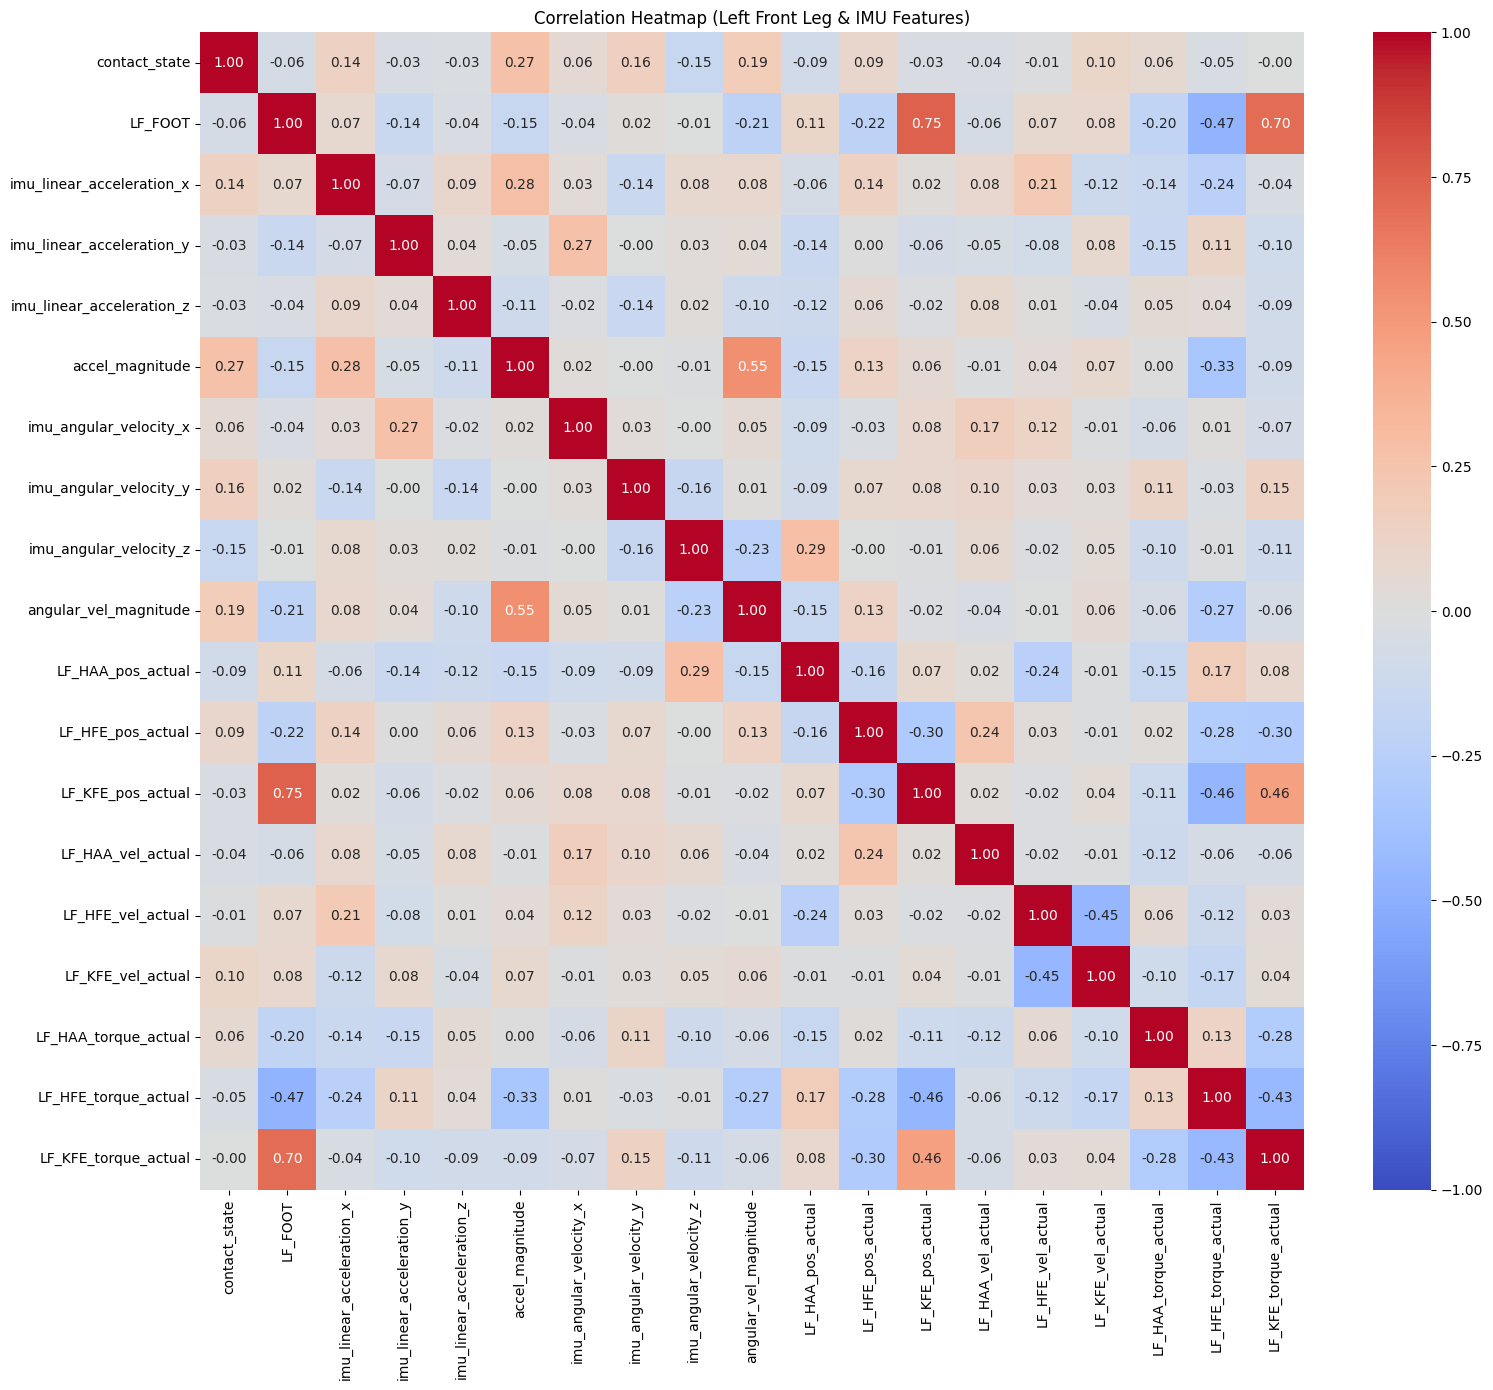

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('left_front_shoulder_1.csv')

# Add the features we discussed
df['contact_state'] = df['physical_contact'].ffill().fillna(0)
df['accel_magnitude'] = np.sqrt(df['imu_linear_acceleration_x']**2 + df['imu_linear_acceleration_y']**2 )  #+ df['imu_linear_acceleration_z']**2)
df['angular_vel_magnitude'] = np.sqrt(df['imu_angular_velocity_x']**2 + df['imu_angular_velocity_y']**2 + df['imu_angular_velocity_z']**2)

# Calculate the full correlation matrix
corr_matrix = df.corr()

# Extract the top 15 highest correlations with contact_state (excluding contact_state itself)
top_lf_corr = corr_matrix['contact_state'].abs().sort_values(ascending=False).head(15)
print("Top features linearly correlated with contact_state:")
print(corr_matrix['contact_state'][top_lf_corr.index])

# Create a heatmap for the relevant Left Front leg and IMU features
subset_features = [
    'contact_state','LF_FOOT',
    'imu_linear_acceleration_x', 'imu_linear_acceleration_y', 'imu_linear_acceleration_z', 'accel_magnitude',
    'imu_angular_velocity_x', 'imu_angular_velocity_y', 'imu_angular_velocity_z', 'angular_vel_magnitude',
    'LF_HAA_pos_actual', 'LF_HFE_pos_actual', 'LF_KFE_pos_actual',
    'LF_HAA_vel_actual', 'LF_HFE_vel_actual', 'LF_KFE_vel_actual',
    'LF_HAA_torque_actual', 'LF_HFE_torque_actual', 'LF_KFE_torque_actual'
]

plt.figure(figsize=(16, 14))
sns.heatmap(df[subset_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Left Front Leg & IMU Features)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')